In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from transformers import T5TokenizerFast, CLIPProcessor, CLIPTokenizerFast, CLIPImageProcessorFast, T5ForConditionalGeneration


from peft import LoraConfig, get_peft_model, TaskType
from torch.amp import autocast, GradScaler
from tqdm import tqdm
import os 
import json

In [2]:
from Modules.config import (TRAIN_IMAGE_DIR,
                            TEST_IMAGE_DIR,
                            FAISS_IMAGE_PATH,
                            TRAIN_METADATA_PATH,
                            TEST_METADATA_PATH,
                            CLIP_MODEL_NAME,
                            T5_MODEL_NAME,
                            VLM_CHECKPOINT_DIR,
                            T5_DECODER_LORA_CONFIG)

from Modules.FusionVLM import FusionVLM, create_default_FusionVLM, load_default_FusionVLM, save_FusionVLM, apply_lora_config, freeze_encoders
from Modules.retrieval_module import Retriever
from Modules.datasets import VLMDataset, VLMDataCollator
from Modules.utils import print_model_param_stats, add_dict
from Modules.metrics import evaluate_captioning, setup_nltk
from Modules.train_VLM import train_and_evaluate_model

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [4]:
CLIP_processor = CLIPImageProcessorFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
CLIP_tokenizer = CLIPTokenizerFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
T5_tokenizer = T5TokenizerFast.from_pretrained(T5_MODEL_NAME, local_files_only=True)

In [5]:
collator_T5 = VLMDataCollator(CLIP_processor, T5_tokenizer, device=DEVICE)
collator_CLIP = VLMDataCollator(CLIP_processor, CLIP_tokenizer, label_tokenizer=T5_tokenizer, max_seq_len=77, device=DEVICE)

collator = collator_T5
# collator = collator_CLIP

In [6]:
retriever = Retriever(metadata_path=TRAIN_METADATA_PATH, faiss_path=FAISS_IMAGE_PATH)

train_dataset = VLMDataset(image_dir=TRAIN_IMAGE_DIR, 
                           ref_image_dir=TRAIN_IMAGE_DIR,
                           metadata_path=TRAIN_METADATA_PATH,
                           retriever=retriever)

test_dataset = VLMDataset(image_dir=TEST_IMAGE_DIR, 
                           ref_image_dir=TRAIN_IMAGE_DIR,
                           metadata_path=TEST_METADATA_PATH,
                           retriever=retriever)

In [7]:
BATCH_SIZE = 16
NUM_WORKERS = 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)

In [8]:
# import numpy as np
# from torch.utils.data import DataLoader, Subset

# num_train_samples = 128
# num_test_samples = 128


# indices = np.random.choice(len(train_dataset), num_train_samples, replace=False)
# train_subset = Subset(train_dataset, indices)
# train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)

# # # indices = np.random.choice(len(test_dataset), num_test_samples, replace=False)
# # # test_subset = Subset(test_dataset, indices)
# # # test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator)

In [9]:
model = create_default_FusionVLM().to(DEVICE)

c:\Users\Mahan\Documents\Projects\Retrieval-Augmented-Image-Captioning\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [10]:
print_model_param_stats(model)

Module                                          Total    Trainable       Frozen
--------------------------------------------------------------------------------
vision_encoder                             87,456,000            0   87,456,000
text_encoder                              109,628,544            0  109,628,544
vision_proj                                   590,592      590,592            0
text_proj                                     590,592      590,592            0
fusion_blocks                              56,724,480   56,724,480            0
post_fusion_ln                                  1,536        1,536            0
fusion_proj                                   590,592      590,592            0
text_decoder                              254,655,744   31,752,192  222,903,552
--------------------------------------------------------------------------------
TOTAL                                     510,238,080   90,249,984  419,988,096


In [11]:
NUM_EPOCHS = 10
full_history = {}
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

setup_nltk()
# os.makedirs(VLM_CHECKPOINT_DIR, exist_ok=True)

In [12]:
history = train_and_evaluate_model(model, train_loader, optimizer, NUM_EPOCHS, test_loader, T5_tokenizer)
add_dict(full_history, history)

Epoch 1: 100%|██████████| 1924/1924 [15:34<00:00,  2.06it/s, loss=2.42]


Avg Loss: 2.41313335
Val Loss: 2.10248758
BLEU-1: 0.6174
BLEU-2: 0.4362
BLEU-3: 0.3161
BLEU-4: 0.2285
METEOR: 0.4379
ROUGE-L: 0.4743
CIDEr: 0.1980


Epoch 2: 100%|██████████| 1924/1924 [15:23<00:00,  2.08it/s, loss=1.8] 


Avg Loss: 2.14592628
Val Loss: 2.08570576
BLEU-1: 0.5628
BLEU-2: 0.3792
BLEU-3: 0.2415
BLEU-4: 0.1553
METEOR: 0.4043
ROUGE-L: 0.4329
CIDEr: 0.1570


Epoch 3: 100%|██████████| 1924/1924 [15:26<00:00,  2.08it/s, loss=2.13]


...

Avg Loss: 1.89291704
Val Loss: 1.98327051
BLEU-1: 0.6202
BLEU-2: 0.4053
BLEU-3: 0.2357
BLEU-4: 0.1409
METEOR: 0.3870
ROUGE-L: 0.4404
CIDEr: 0.1972


Epoch 9: 100%|██████████| 1924/1924 [15:41<00:00,  2.04it/s, loss=2.05]


Avg Loss: 1.87842592
Val Loss: 1.97443280
BLEU-1: 0.6754
BLEU-2: 0.4890
BLEU-3: 0.3535
BLEU-4: 0.2557
METEOR: 0.4573
ROUGE-L: 0.4945
CIDEr: 0.2765


Epoch 10: 100%|██████████| 1924/1924 [15:41<00:00,  2.04it/s, loss=2.07]


Avg Loss: 1.85061202
Val Loss: 2.02067748
BLEU-1: 0.6607
BLEU-2: 0.4788
BLEU-3: 0.3507
BLEU-4: 0.2570
METEOR: 0.4445
ROUGE-L: 0.4966
CIDEr: 0.2502


In [13]:
with open('history0-10.json', "w", encoding="utf-8") as f:
    json.dump(full_history, f, indent=2, ensure_ascii=False)

In [ ]:
NUM_EPOCHS = 5
history = train_and_evaluate_model(model, train_loader, optimizer, NUM_EPOCHS, test_loader, T5_tokenizer, save_interval=1)
add_dict(full_history, history)

In [14]:
hist = {}
for key in full_history.keys():
    # hist[key] = full_history[key][0] + full_history[key][1]
    hist[key] = full_history[key][0]

In [15]:
with open('history0-10-hist.json', "w", encoding="utf-8") as f:
    json.dump(hist, f, indent=2, ensure_ascii=False)

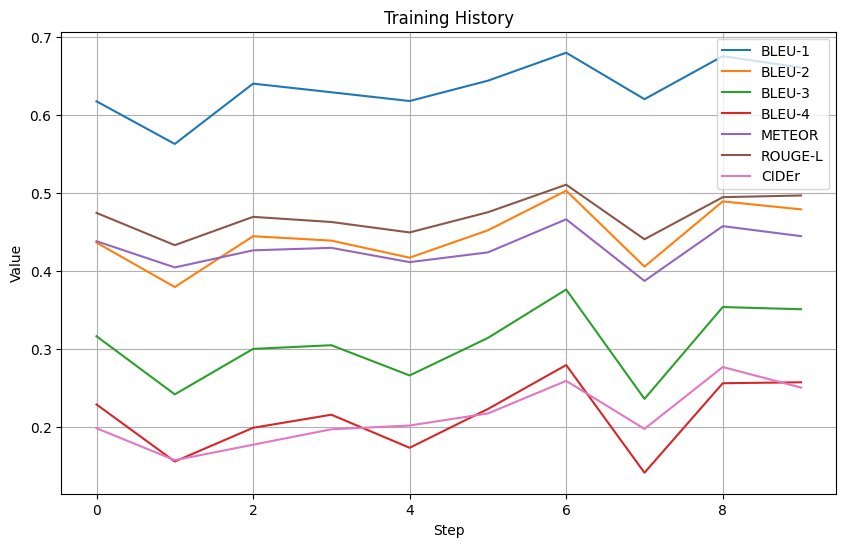

In [30]:
import matplotlib.pyplot as plt

# for key in hist.keys():
#     plt.plot(hist[key])
#     plt.title(key)
#     plt.show()

plt.figure(figsize=(10, 6))

for key, values in hist.items():
    if key != 'train_loss' and key != 'val_loss':
        plt.plot(values, label=key)

plt.title("Training History")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


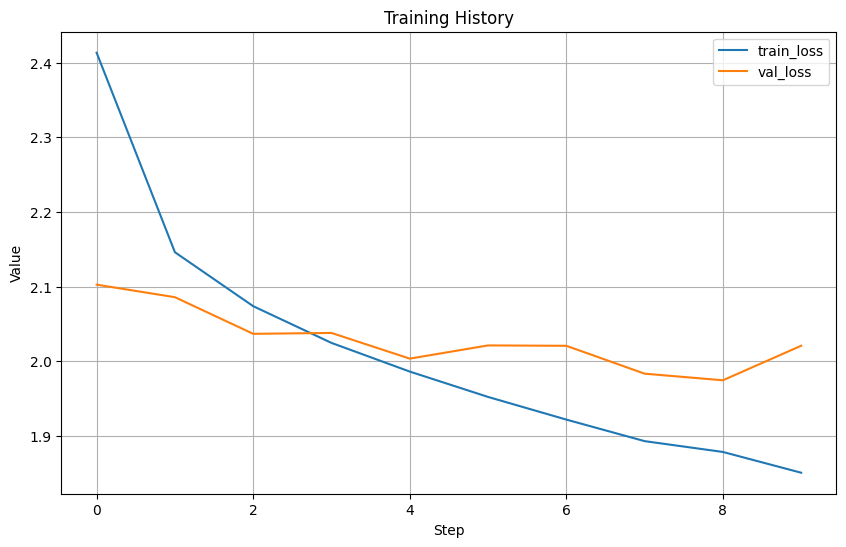

In [32]:
plt.figure(figsize=(10, 6))

for key, values in hist.items():
    if key == 'train_loss' or key == 'val_loss':
        plt.plot(values, label=key)

plt.title("Training History")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

### Exepriments

In [17]:
loaded = load_default_FusionVLM('epoch10')

c:\Users\Mahan\Documents\Projects\Retrieval-Augmented-Image-Captioning\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


In [18]:
model.eval()
loaded.eval()

model.cpu()
loaded.cpu()

FusionVLM(
  (vision_encoder): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (position_embedding): Embedding(50, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              

In [19]:
def same_architecture(model_a, model_b):
    keys_a = list(model_a.state_dict().keys())
    keys_b = list(model_b.state_dict().keys())
    return keys_a == keys_b

print("Same architecture:", same_architecture(model, loaded))

Same architecture: True


In [20]:
def same_shapes(model_a, model_b):
    sd_a = model_a.state_dict()
    sd_b = model_b.state_dict()

    for k in sd_a:
        if sd_a[k].shape != sd_b[k].shape:
            print(f"Shape mismatch at {k}: {sd_a[k].shape} vs {sd_b[k].shape}")
            return False
    return True

print("Same tensor_shape:", same_shapes(model, loaded))


Same tensor_shape: True


In [21]:
def same_weights_exact(model_a, model_b):
    for (ka, va), (kb, vb) in zip(
        model_a.state_dict().items(),
        model_b.state_dict().items()
    ):
        if not torch.equal(va, vb):
            print(f"Mismatch at {ka}")
            return False
    return True

print("Exact same weights:", same_weights_exact(model, loaded))

Exact same weights: True


In [22]:
model.to(DEVICE)
loaded.to(DEVICE)

FusionVLM(
  (vision_encoder): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (position_embedding): Embedding(50, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              

In [24]:
with torch.no_grad():
    for batch in test_loader:
        gt_captions = batch["all_captions"]  # List[List[str]]

        generated_ids_o = model.generate(
            query_pixel_values=batch["query_pixel_values"],
            retrieved_pixel_values=batch.get("retrieved_pixel_valuess"),
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_length=None,
            max_new_tokens=64,
            # do_sample=True,
            # temperature=0.9,
            # top_p=0.9,
            # num_beams=4,
            early_stopping=True,
            length_penalty=1.2, # longer outputs 
            repetition_penalty=1.2 # penalize repeats
        )
        
        generated_ids_l = loaded.generate(
            query_pixel_values=batch["query_pixel_values"],
            retrieved_pixel_values=batch.get("retrieved_pixel_valuess"),
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_length=None,
            max_new_tokens=64,
            # do_sample=True,
            # temperature=0.9,
            # top_p=0.9,
            # num_beams=4,
            early_stopping=True,
            length_penalty=1.2, # longer outputs 
            repetition_penalty=1.2 # penalize repeats
        )

        decoded_o = T5_tokenizer.batch_decode(generated_ids_o, skip_special_tokens=True)
        decoded_l = T5_tokenizer.batch_decode(generated_ids_l, skip_special_tokens=True)
        for i in range(len(decoded_o)):
            print(gt_captions[i][0])
            print(decoded_o[i])   
            print(decoded_l[i])   
            print()         
        break

A picture of A dark hair woman  dressed in white boots and a black and green dress  is striking a dancer pose for the camera .
A picture of asian woman in a green shirt is dancing .
A picture of asian woman in a green shirt is dancing .

A picture of Three large black dogs are playing in the grass .
A picture of a black and white dog is running .
A picture of a black and white dog is running .

A picture of A man in a green shirt  holding a bike in front of him  looking towards an officer talking to several young men .
A picture ofs a man and a woman are standing in a building .
A picture ofs a man and a woman are standing in a building .

A picture of A female in a pink shirt and black pants in a harness looks thrilled .
A picture ofs a woman in a blue shirt is wearing a t-shirt .
A picture ofs a woman in a blue shirt is wearing a t-shirt .

A picture of The Elmo t-shirted dirt bike rider racing through on the wooded path  leaps easily over an obstacle on his path .
A picture of a wom

In [ ]:
with torch.no_grad():
    for batch in test_loader:
        gt_captions = batch["all_captions"]  # List[List[str]]

        generated_ids = model_loaded.generate(
            query_pixel_values=batch["query_pixel_values"],
            retrieved_pixel_values=batch.get("retrieved_pixel_valuess"),
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_length=None,
            max_new_tokens=64,
            do_sample=True,
            temperature=0.9,
            top_p=0.9,
            num_beams=4,
            early_stopping=True,
            length_penalty=1.2, # longer outputs 
            repetition_penalty=1.2 # penalize repeats
        )

        decoded = T5_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        for i in range(len(decoded)):
            print(gt_captions[i][0])
            print(decoded[i])   
            print()         
        break

In [ ]:
setup_nltk()

In [25]:
def evaluate_model(model, loader, tokenizer):
    model.eval()

    preds = []
    refs = []

    with torch.no_grad():
        for batch in loader:
            gt_captions = batch.get("all_captions")  # List[List[str]]
            
            generated_ids = model.generate(
                    query_pixel_values=batch.get("query_pixel_values"),
                    retrieved_pixel_values=batch.get("retrieved_pixel_values"),
                    input_ids=batch.get("input_ids"),
                    attention_mask=batch.get("attention_mask"),
                    max_length=None,
                    max_new_tokens=64,
                    # do_sample=True,
                    # temperature=1.0,
                    # top_p=0.9,
                    # num_beams=4,
                    # early_stopping=True,
                    # length_penalty=1.2, # longer outputs 
                    # repetition_penalty=1.2 # penalize repeats
            )

            decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            preds.extend(decoded)
            refs.extend(gt_captions)
            # refs.extend([[max(caption, key=len)] for caption in gt_captions])
            
    return evaluate_captioning(preds, refs)

In [26]:
metrics = evaluate_model(model, test_loader, T5_tokenizer)

In [27]:
metrics_loaded = evaluate_model(loaded, test_loader, T5_tokenizer)

In [28]:
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

BLEU-1: 0.6030
BLEU-2: 0.4388
BLEU-3: 0.3220
BLEU-4: 0.2348
METEOR: 0.4320
ROUGE-L: 0.4864
CIDEr: 0.2355


In [29]:
for k, v in metrics_loaded.items():
    print(f"{k}: {v:.4f}")

BLEU-1: 0.6030
BLEU-2: 0.4388
BLEU-3: 0.3220
BLEU-4: 0.2348
METEOR: 0.4320
ROUGE-L: 0.4864
CIDEr: 0.2355
